In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Đọc file tổng
df = pd.read_csv('all_stocks_5yr.csv')
df['date'] = pd.to_datetime(df['date'])
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'all_stocks_5yr.csv'

In [ ]:
print("Số lượng giá trị thiếu ở từng cột:")
print(df.isnull().sum())


In [ ]:
# 1. Loại bỏ các dòng có chứa bất kỳ giá trị Null nào (Trang 11 Pandas)
df.dropna(inplace=True)

# 2. Kiểm tra lại để chắc chắn không còn giá trị thiếu
print("Số lượng giá trị thiếu sau khi xử lý:")
print(df.isnull().sum())

# 3. Sắp xếp lại dữ liệu theo mã chứng khoán và thời gian để đảm bảo tính liên tục
df = df.sort_values(['Name', 'date'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 504421 entries, 71611 to 504427
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    504421 non-null  datetime64[ns]
 1   open    504421 non-null  float64       
 2   high    504421 non-null  float64       
 3   low     504421 non-null  float64       
 4   close   504421 non-null  float64       
 5   volume  504421 non-null  int64         
 6   Name    504421 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 30.8+ MB


In [ ]:
# 1. Thống kê mô tả cho các biến định lượng (open, high, low, close, volume)
# Dùng .T (Transpose) để xoay bảng lại cho dễ đọc hơn nếu có nhiều cột (Trang 2 Pandas)
summary_stats = df[['open', 'high', 'low', 'close', 'volume']].describe().T
print("Bảng thống kê mô tả các biến số gốc:")
print(summary_stats)

# 2. Thống kê cho biến định tính (mã cổ phiếu Name)
# Giúp biết có bao nhiêu mã, mã nào xuất hiện nhiều nhất
print("\nThống kê cho biến định tính (Name):")
print(df['Name'].describe())

# 3. (Nâng cao) Xem giá đóng cửa trung bình của một vài mã tiêu biểu
top_tech = df[df['Name'].isin(['AAPL', 'GOOGL', 'MSFT'])]
print("\nGiá đóng cửa trung bình của một số mã công nghệ:")
print(top_tech.groupby('Name')['close'].mean())

Bảng thống kê mô tả các biến số gốc:
           count          mean           std     min         25%         50%  \
open    504421.0  8.457899e+01  1.059599e+02    1.62       38.96       61.11   
high    504421.0  8.534830e+01  1.068614e+02    1.69       39.34       61.69   
low     504421.0  8.379698e+01  1.050124e+02    1.50       38.56       60.55   
close   504421.0  8.459923e+01  1.059708e+02    1.59       38.97       61.14   
volume  504421.0  4.514197e+06  9.302733e+06  101.00  1080904.00  2107179.00   

                 75%           max  
open    9.369000e+01  2.044000e+03  
high    9.449950e+01  2.067990e+03  
low     9.289000e+01  2.035110e+03  
close   9.373000e+01  2.049000e+03  
volume  4.362126e+06  4.313326e+08  

Thống kê cho biến định tính (Name):
count     504421
unique       413
top          SEE
freq        1259
Name: Name, dtype: object

Giá đóng cửa trung bình của một số mã công nghệ:
Name
AAPL     109.066698
GOOGL    682.233847
MSFT      51.063081
Name: close, d

10 mã cổ phiếu có tần suất xuất hiện nhiều nhất:
Name
SEE     1259
A       1259
AAL     1259
AAP     1259
AAPL    1259
ABBV    1259
ABC     1259
ABT     1259
ACN     1259
ADBE    1259
Name: count, dtype: int64


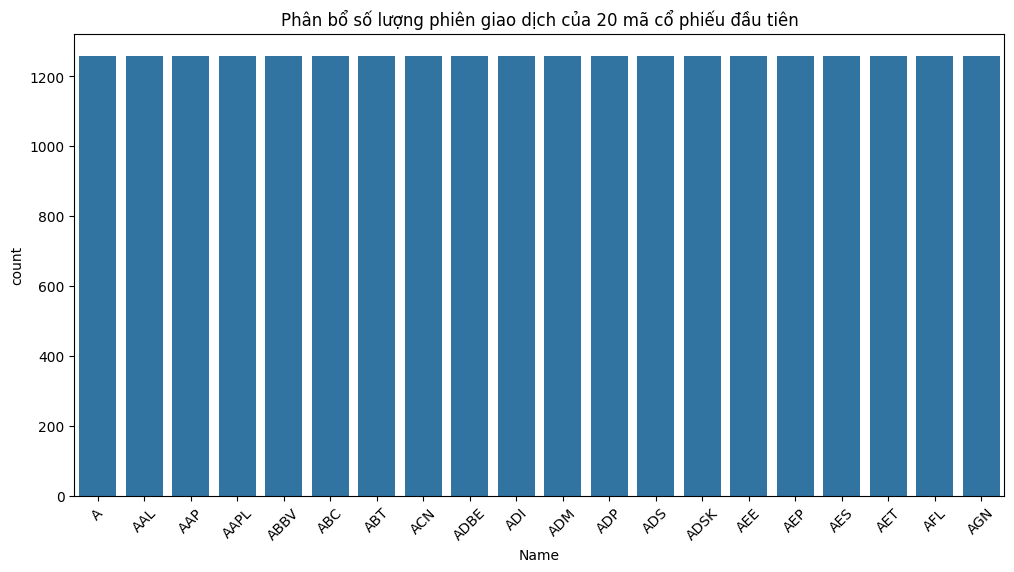

In [ ]:
# 1. Thống kê số lượng quan sát của mỗi mã (Pandas - Trang 11)
ticker_dist = df['Name'].value_counts()
print("10 mã cổ phiếu có tần suất xuất hiện nhiều nhất:")
print(ticker_dist.head(10))

# 2. Vẽ biểu đồ phân bổ tần suất của 20 mã đầu tiên (Seaborn - Countplot)
plt.figure(figsize=(12, 6))
sns.countplot(data=df[df['Name'].isin(df['Name'].unique()[:20])], x='Name')
plt.title('Phân bổ số lượng phiên giao dịch của 20 mã cổ phiếu đầu tiên')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# 2. Tính Tỷ suất sinh lời hàng ngày cho TỪNG mã cổ phiếu (Groupby - Trang 6 Pandas)
# Chúng ta nhóm theo cột 'Name' để việc tính toán không bị lẫn lộn giữa mã này với mã kia
df['Daily_Return'] = df.groupby('Name')['close'].pct_change()

# 3. Tính Đường trung bình động 50 ngày cho từng mã
df['MA50'] = df.groupby('Name')['close'].transform(lambda x: x.rolling(window=50).mean())

# Xem thử kết quả của toàn bộ các mã
print("Danh sách các mã cổ phiếu có trong dữ liệu:")
print(df['Name'].unique())
df.head()

Danh sách các mã cổ phiếu có trong dữ liệu:
['A' 'AAL' 'AAP' 'AAPL' 'ABBV' 'ABC' 'ABT' 'ACN' 'ADBE' 'ADI' 'ADM' 'ADP'
 'ADS' 'ADSK' 'AEE' 'AEP' 'AES' 'AET' 'AFL' 'AGN' 'AIG' 'AIV' 'AIZ' 'AJG'
 'AKAM' 'ALB' 'ALGN' 'ALK' 'ALL' 'ALLE' 'ALXN' 'AMAT' 'AMD' 'AME' 'AMG'
 'AMGN' 'AMP' 'AMT' 'AMZN' 'ANDV' 'ANSS' 'ANTM' 'AON' 'AOS' 'APA' 'APC'
 'APD' 'APH' 'APTV' 'ARE' 'ARNC' 'ATVI' 'AVB' 'AVGO' 'AVY' 'AWK' 'AXP'
 'AYI' 'AZO' 'BA' 'BAC' 'BAX' 'BBT' 'BBY' 'BDX' 'BEN' 'BF.B' 'BHF' 'BHGE'
 'BIIB' 'BK' 'BLK' 'BLL' 'BMY' 'BRK.B' 'BSX' 'BWA' 'BXP' 'C' 'CA' 'CAG'
 'CAH' 'CAT' 'CB' 'CBG' 'CBOE' 'CBS' 'CCI' 'CCL' 'CDNS' 'CELG' 'CERN' 'CF'
 'CFG' 'CHD' 'CHK' 'CHRW' 'CHTR' 'CI' 'CINF' 'CL' 'CLX' 'CMA' 'CMCSA'
 'CME' 'CMG' 'CMI' 'CMS' 'CNC' 'CNP' 'COF' 'COG' 'COL' 'COO' 'COP' 'COST'
 'COTY' 'CPB' 'CRM' 'CSCO' 'CSRA' 'CSX' 'CTAS' 'CTL' 'CTSH' 'CTXS' 'CVS'
 'CVX' 'CXO' 'D' 'DAL' 'DE' 'DFS' 'DG' 'DGX' 'DHI' 'DHR' 'DIS' 'DISCA'
 'DISCK' 'DISH' 'DLR' 'DLTR' 'DOV' 'DPS' 'DRE' 'DRI' 'DTE' 'DUK' 'DVA'
 'DVN' 'DWDP'

,date,open,high,low,close,volume,Name,Daily_Return,MA50
71611,2013-02-08,45.07,45.35,45.00,45.08,1824755,A,NaN,NaN
71612,2013-02-11,45.17,45.18,44.45,44.60,2915405,A,-0.010648,NaN
71613,2013-02-12,44.81,44.95,44.50,44.62,2373731,A,0.000448,NaN
71614,2013-02-13,44.81,45.24,44.68,44.75,2052338,A,0.002913,NaN
71615,2013-02-14,44.72,44.78,44.36,44.58,3826245,A,-0.003799,NaN


In [ ]:
df.dropna(inplace=True)
print(df.isnull().sum())
print(df.head())

date            0
open            0
high            0
low             0
close           0
volume          0
Name            0
Daily_Return    0
MA50            0
dtype: int64
            date   open     high    low  close   volume Name  Daily_Return  \
71660 2013-04-22  42.03  42.2500  41.34  41.85  2340457    A     -0.003571   
71661 2013-04-23  42.21  42.8425  42.13  42.61  3522419    A      0.018160   
71662 2013-04-24  42.72  43.0350  42.37  42.85  3020692    A      0.005632   
71663 2013-04-25  43.05  43.2500  42.66  42.73  2119838    A     -0.002800   
71664 2013-04-26  42.44  42.5700  40.69  41.30  5283798    A     -0.033466   

          MA50  
71660  42.4326  
71661  42.3832  
71662  42.3482  
71663  42.3104  
71664  42.2414  


Các mã tìm thấy và sẽ vẽ biểu đồ: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'FB', 'JPM', 'KO', 'PEP']


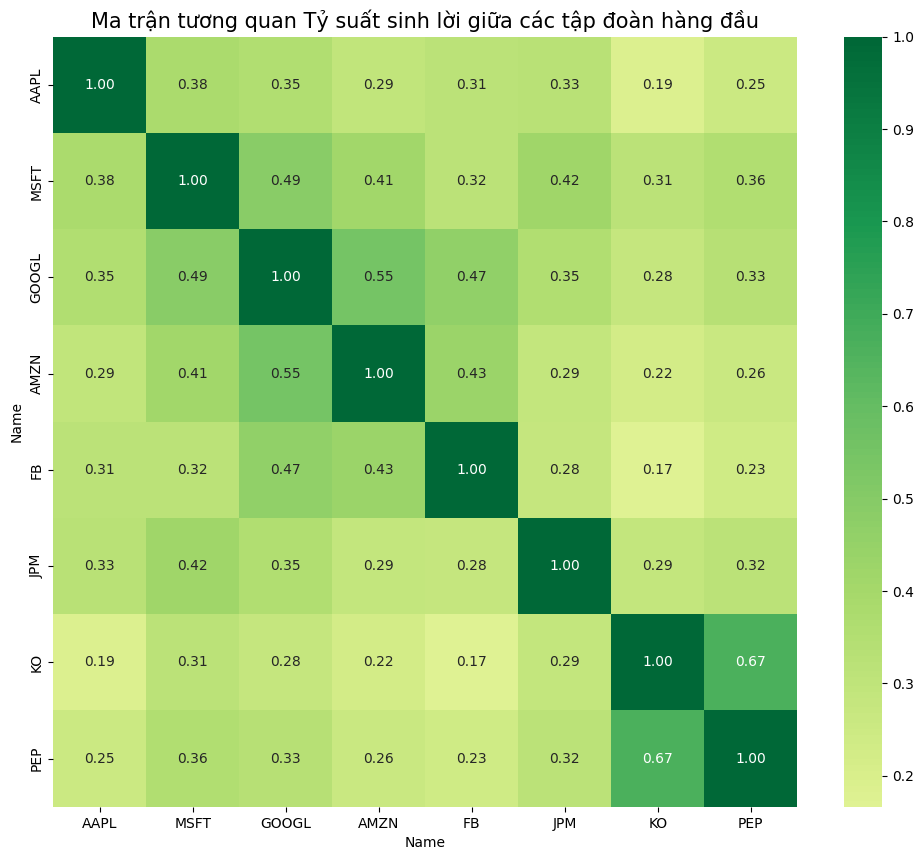

In [ ]:

target_tags = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'FB', 'JPM', 'V', 'KO', 'WMT', 'PEP']
actual_tags = [t for t in target_tags if t in pivot_returns.columns]
print("Các mã tìm thấy và sẽ vẽ biểu đồ:", actual_tags)
df_corr = pivot_returns[actual_tags].corr()
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(df_corr, annot=True, cmap='RdYlGn', center=0, fmt=".2f")
plt.title('Ma trận tương quan Tỷ suất sinh lời giữa các tập đoàn hàng đầu', fontsize=15)
plt.savefig('heatmap_tuong_quan.png', dpi=300, bbox_inches='tight')
plt.show()

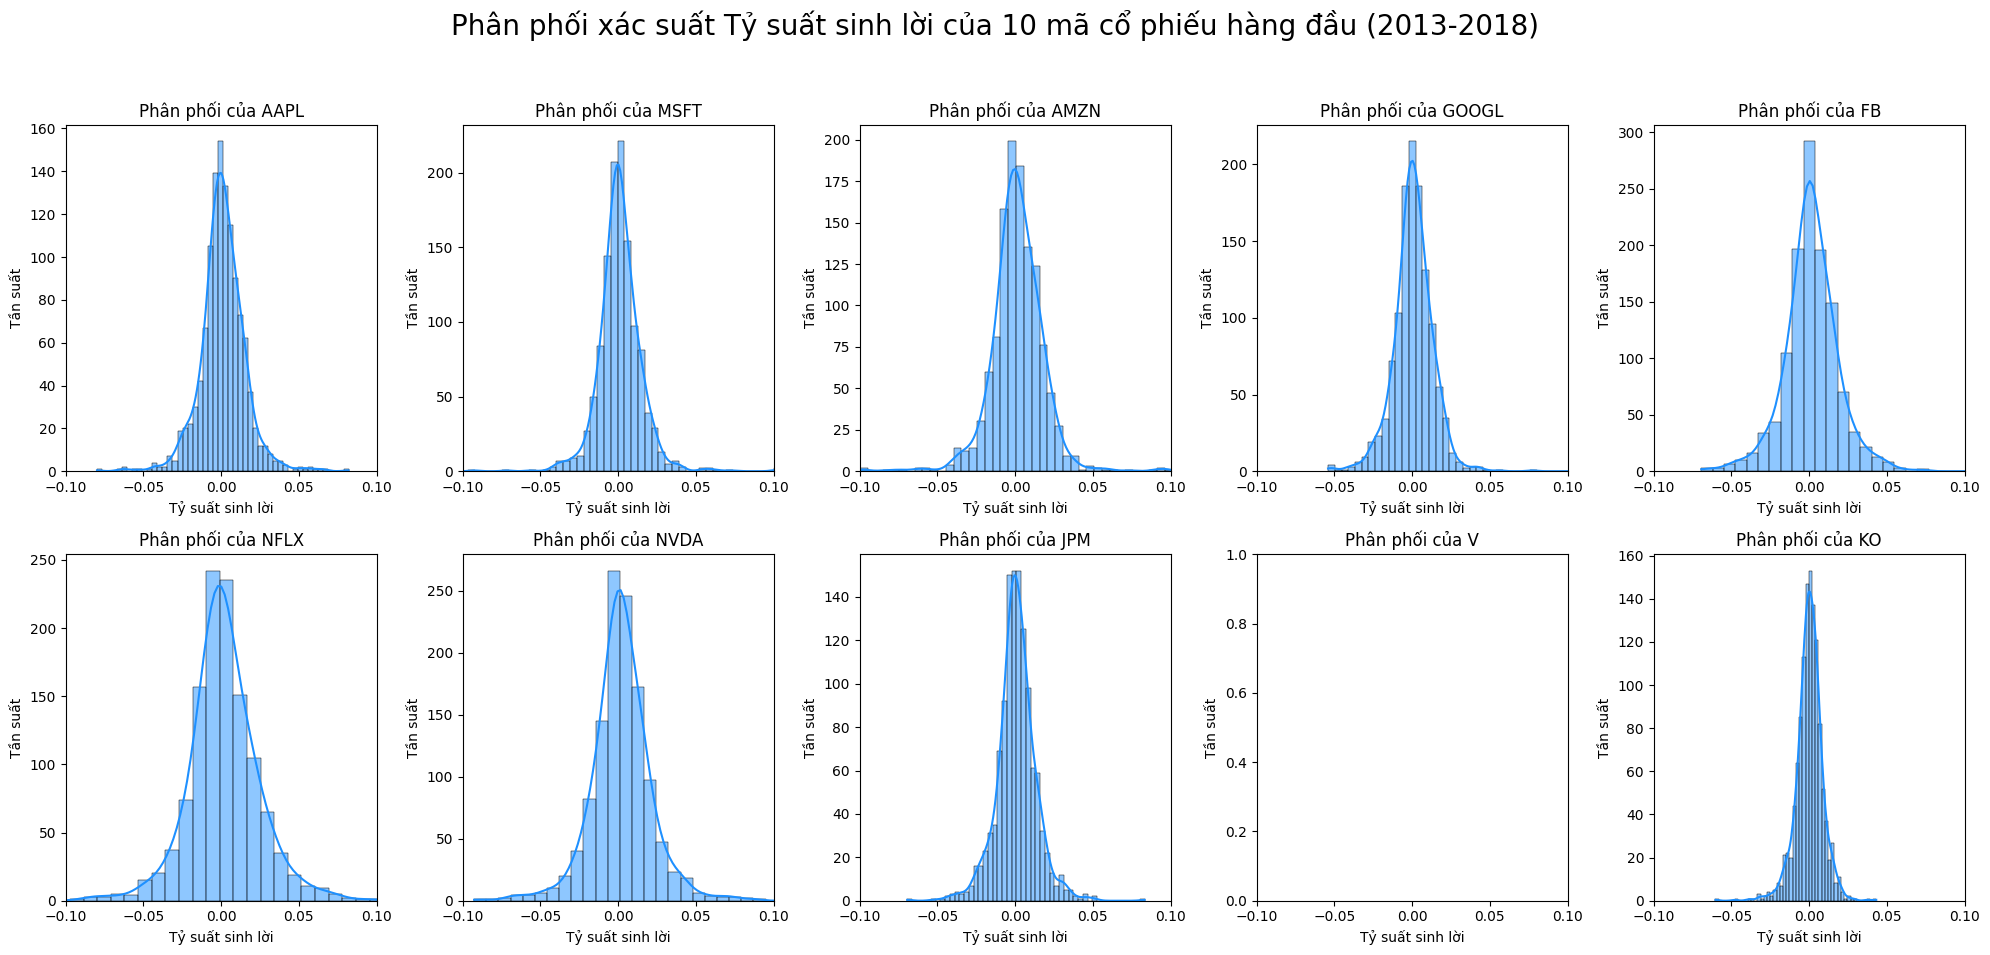

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

top_10_stocks = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'FB', 'NFLX', 'NVDA', 'JPM', 'V', 'KO']
df_10 = df[df['Name'].isin(top_10_stocks)]
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
fig.suptitle('Phân phối xác suất Tỷ suất sinh lời của 10 mã cổ phiếu hàng đầu (2013-2018)', fontsize=20)

for i, ticker in enumerate(top_10_stocks):
    row = i // 5
    col = i % 5
    data_ticker = df_10[df_10['Name'] == ticker]['Daily_Return']
    sns.histplot(data_ticker, kde=True, ax=axes[row, col], color='dodgerblue', bins=50)
    axes[row, col].set_title(f'Phân phối của {ticker}')
    axes[row, col].set_xlim([-0.1, 0.1]) # Giới hạn biên độ để dễ so sánh
    axes[row, col].set_xlabel('Tỷ suất sinh lời')
    axes[row, col].set_ylabel('Tần suất')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

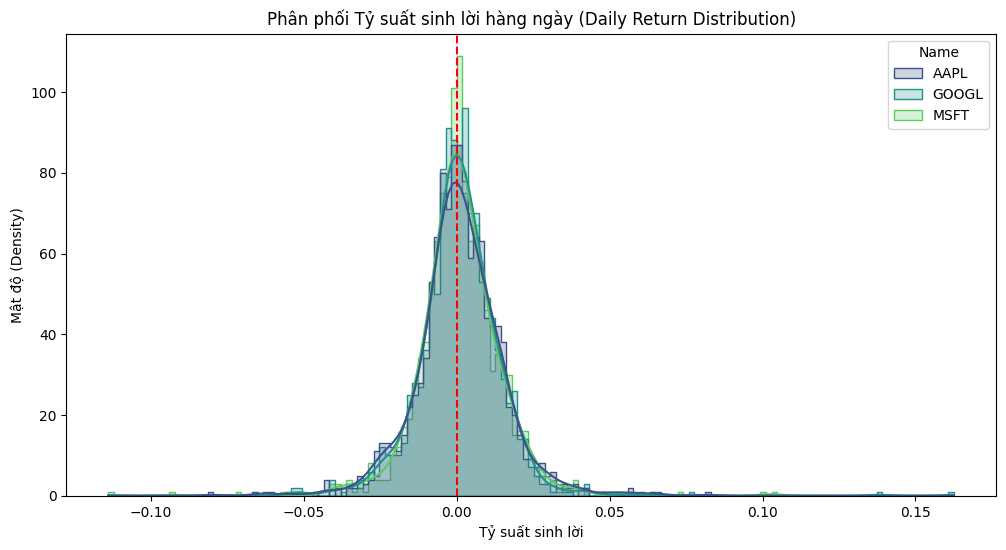

In [ ]:
# Chọn 3 mã công nghệ tiêu biểu để xem phân phối lợi nhuận (Seaborn - Distplot/Histplot)
selected_stocks = ['AAPL', 'GOOGL', 'MSFT']
df_selected = df[df['Name'].isin(selected_stocks)]

plt.figure(figsize=(12, 6))

# Vẽ biểu đồ phân phối KDE (Kernel Density Estimate - Trang 15 tài liệu PDF)
# kde=True giúp vẽ đường cong mềm mại bao quanh biểu đồ cột
sns.histplot(data=df_selected, x='Daily_Return', hue='Name', kde=True, element="step", palette="viridis")

plt.title('Phân phối Tỷ suất sinh lời hàng ngày (Daily Return Distribution)')
plt.xlabel('Tỷ suất sinh lời')
plt.ylabel('Mật độ (Density)')
plt.axvline(0, color='red', linestyle='--') # Đường kẻ tại mức 0 (không lãi không lỗ)
plt.show()

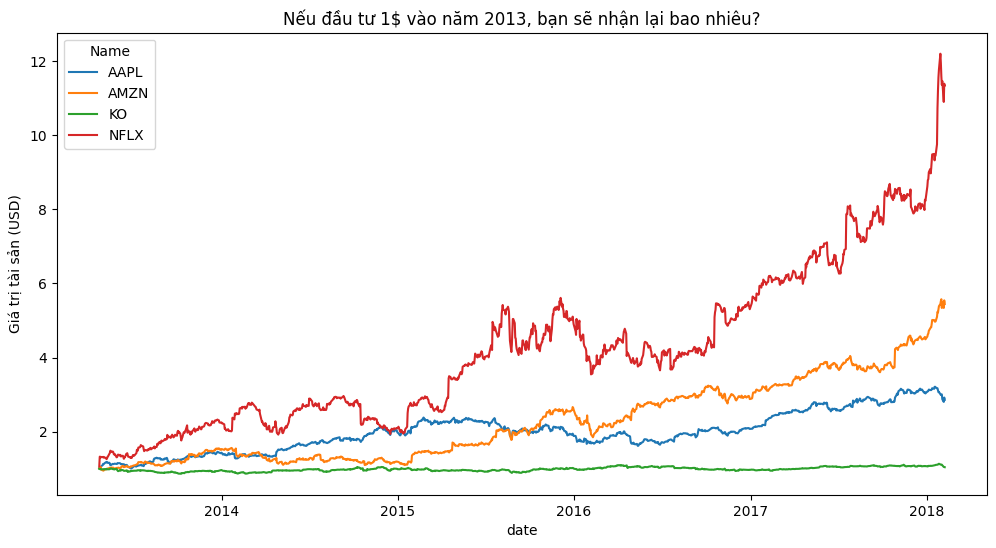

In [ ]:
df_growth = df[df['Name'].isin(['AAPL', 'AMZN', 'NFLX', 'KO'])].copy()
df_growth['Cumulative_Return'] = df_growth.groupby('Name')['Daily_Return'].transform(lambda x: (1 + x).cumprod())

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_growth, x='date', y='Cumulative_Return', hue='Name')
plt.title('Nếu đầu tư 1$ vào năm 2013, bạn sẽ nhận lại bao nhiêu?')
plt.ylabel('Giá trị tài sản (USD)')
plt.show()

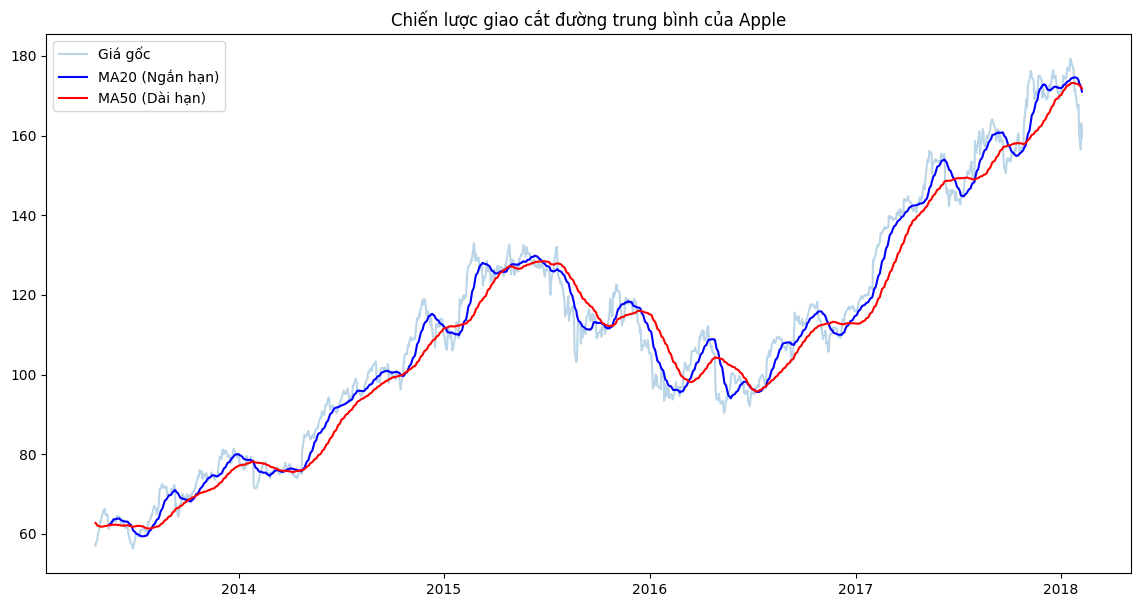

In [ ]:

aapl = df[df['Name'] == 'AAPL'].copy()
aapl['MA20'] = aapl['close'].rolling(window=20).mean()

plt.figure(figsize=(14, 7))
plt.plot(aapl['date'], aapl['close'], label='Giá gốc', alpha=0.3)
plt.plot(aapl['date'], aapl['MA20'], label='MA20 (Ngắn hạn)', color='blue')
plt.plot(aapl['date'], aapl['MA50'], label='MA50 (Dài hạn)', color='red')
plt.title('Chiến lược giao cắt đường trung bình của Apple')
plt.legend()
plt.show()

In [ ]:
amzn = df[df['Name'] == 'AAPL']
sns.jointplot(data=amzn, x='volume', y='Daily_Return', kind='hex', color='#4CB391')
plt.show()

Các mã tìm thấy và sẽ đưa vào biểu đồ: ['AAPL', 'AMZN', 'MSFT', 'KO']


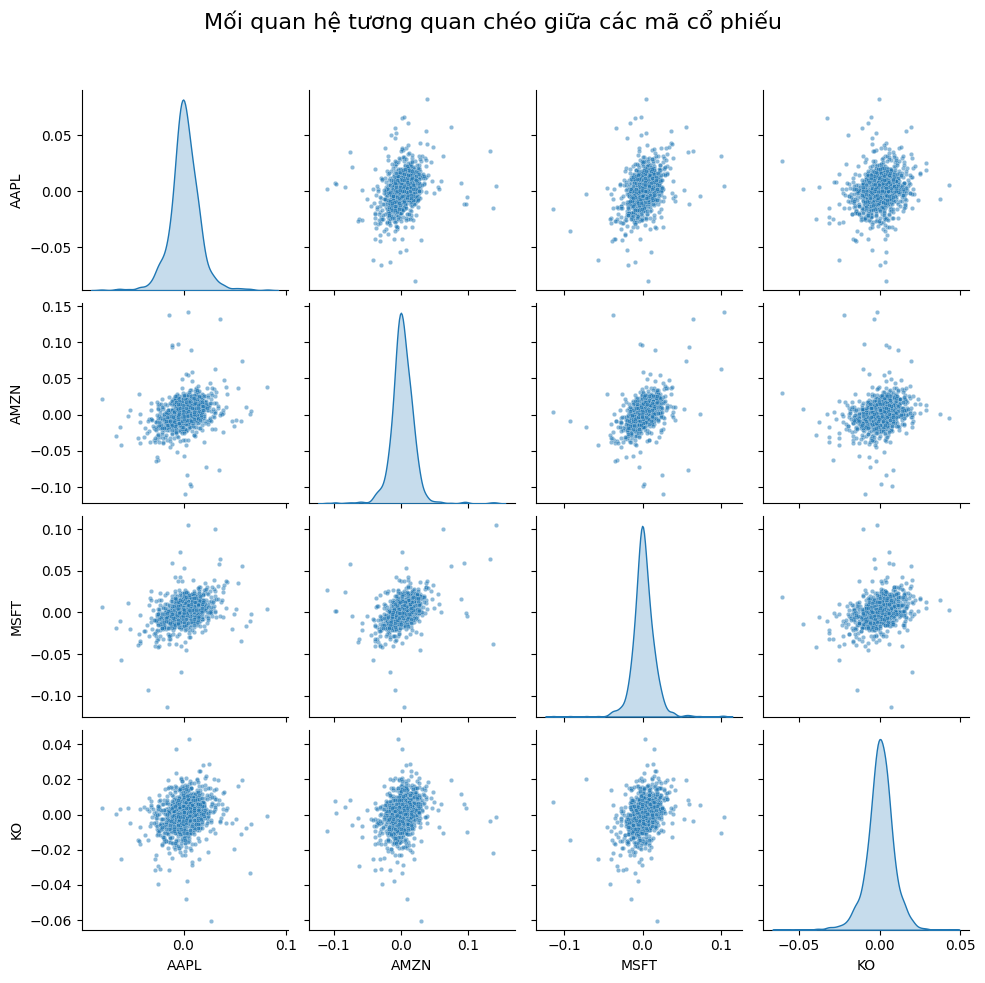

In [ ]:
# 1. Danh sách các mã bạn muốn lấy
target_tickers = ['AAPL', 'AMZN', 'MSFT', 'KO']

available_tickers = [t for t in target_tickers if t in pivot_returns.columns]

print("Các mã tìm thấy và sẽ đưa vào biểu đồ:", available_tickers)

# 3. Lọc lại dữ liệu với những mã có sẵn
tech_stocks = pivot_returns[available_tickers]

# 4. Vẽ Pairplot (Trang 1 Seaborn)
sns.pairplot(tech_stocks, diag_kind='kde', plot_kws={'alpha': 0.5, 's': 10})
plt.subplots_adjust(top=0.9)
plt.suptitle('Mối quan hệ tương quan chéo giữa các mã cổ phiếu', fontsize=16)
plt.show()

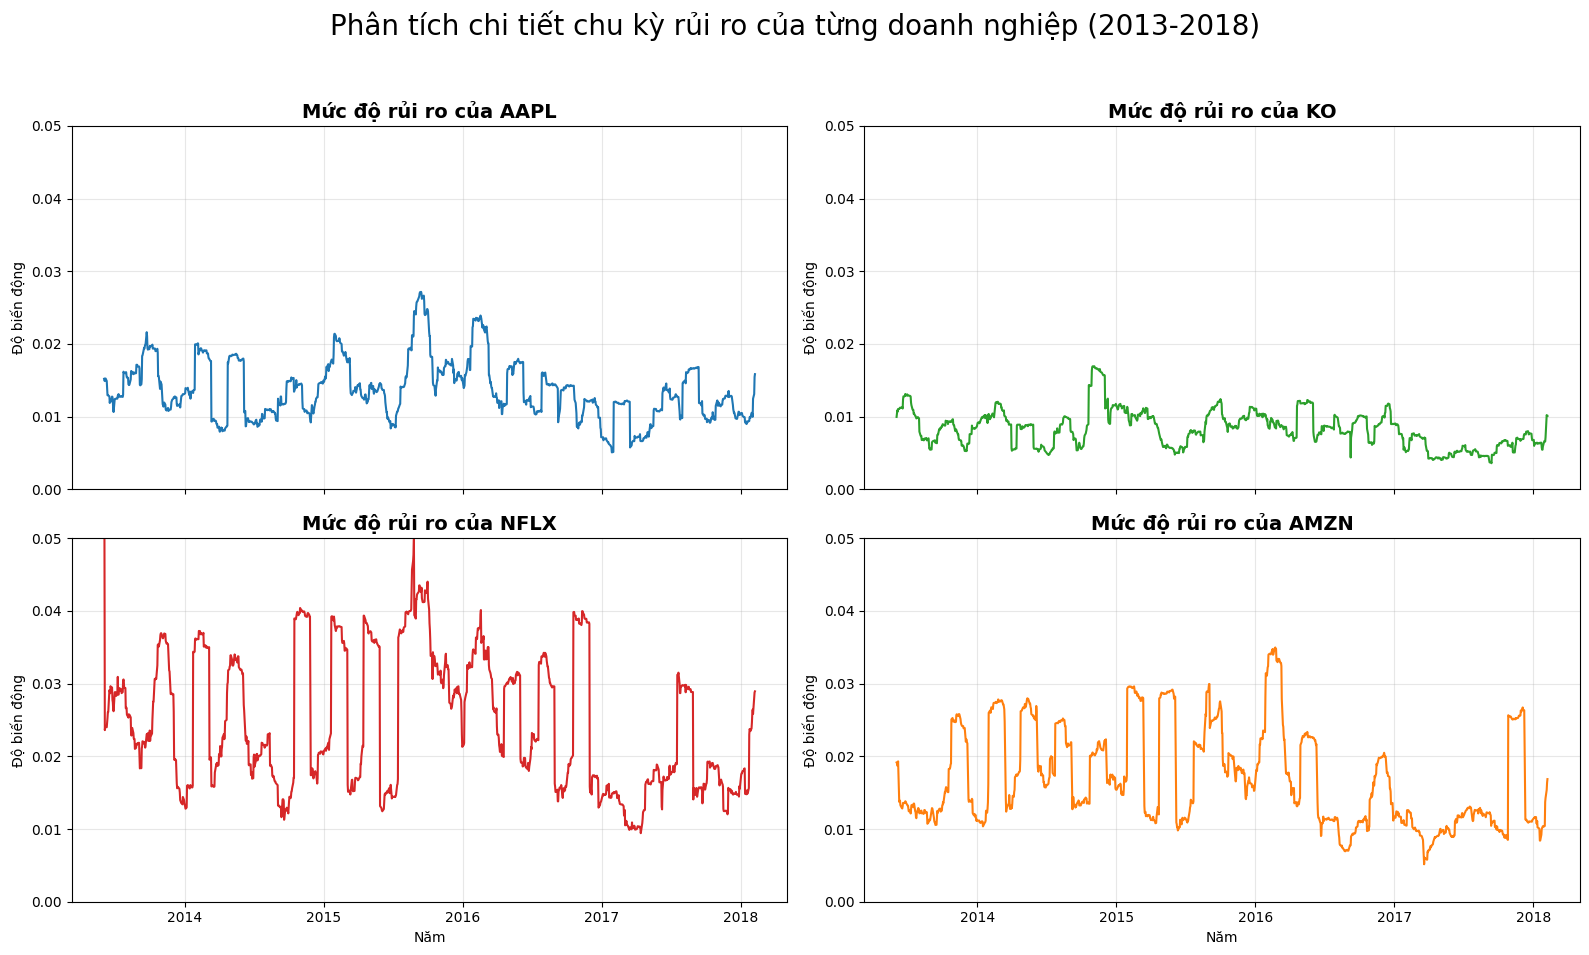

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chuẩn bị dữ liệu 4 mã
selected_list = ['AAPL', 'KO', 'NFLX', 'AMZN']
df_4 = df[df['Name'].isin(selected_list)].copy()

# 2. Tính rủi ro biến động (Volatility) trượt 30 ngày cho từng mã
df_4['Rolling_Volatility'] = df_4.groupby('Name')['Daily_Return'].transform(lambda x: x.rolling(window=30).std())

# 3. Thiết lập khung hình 2 hàng, 2 cột (Trang 1 Matplotlib)
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
fig.suptitle('Phân tích chi tiết chu kỳ rủi ro của từng doanh nghiệp (2013-2018)', fontsize=20)

# Danh sách màu sắc cho từng hãng
colors = ['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e']

# 4. Vòng lặp vẽ từng biểu đồ
for i, ticker in enumerate(selected_list):
    row, col = i // 2, i % 2
    data_ticker = df_4[df_4['Name'] == ticker]

    # Vẽ đường biến động
    sns.lineplot(data=data_ticker, x='date', y='Rolling_Volatility',
                 ax=axes[row, col], color=colors[i], linewidth=1.5)

    # Tùy chỉnh thẩm mỹ cho từng ô
    axes[row, col].set_title(f'Mức độ rủi ro của {ticker}', fontsize=14, fontweight='bold')
    axes[row, col].set_ylabel('Độ biến động')
    axes[row, col].set_xlabel('Năm')
    axes[row, col].grid(True, alpha=0.3)

    # Giới hạn trục Y giống nhau để dễ so sánh độ cao thấp giữa các hãng
    axes[row, col].set_ylim(0, 0.05)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('separated_volatility.png', dpi=300)
plt.show()

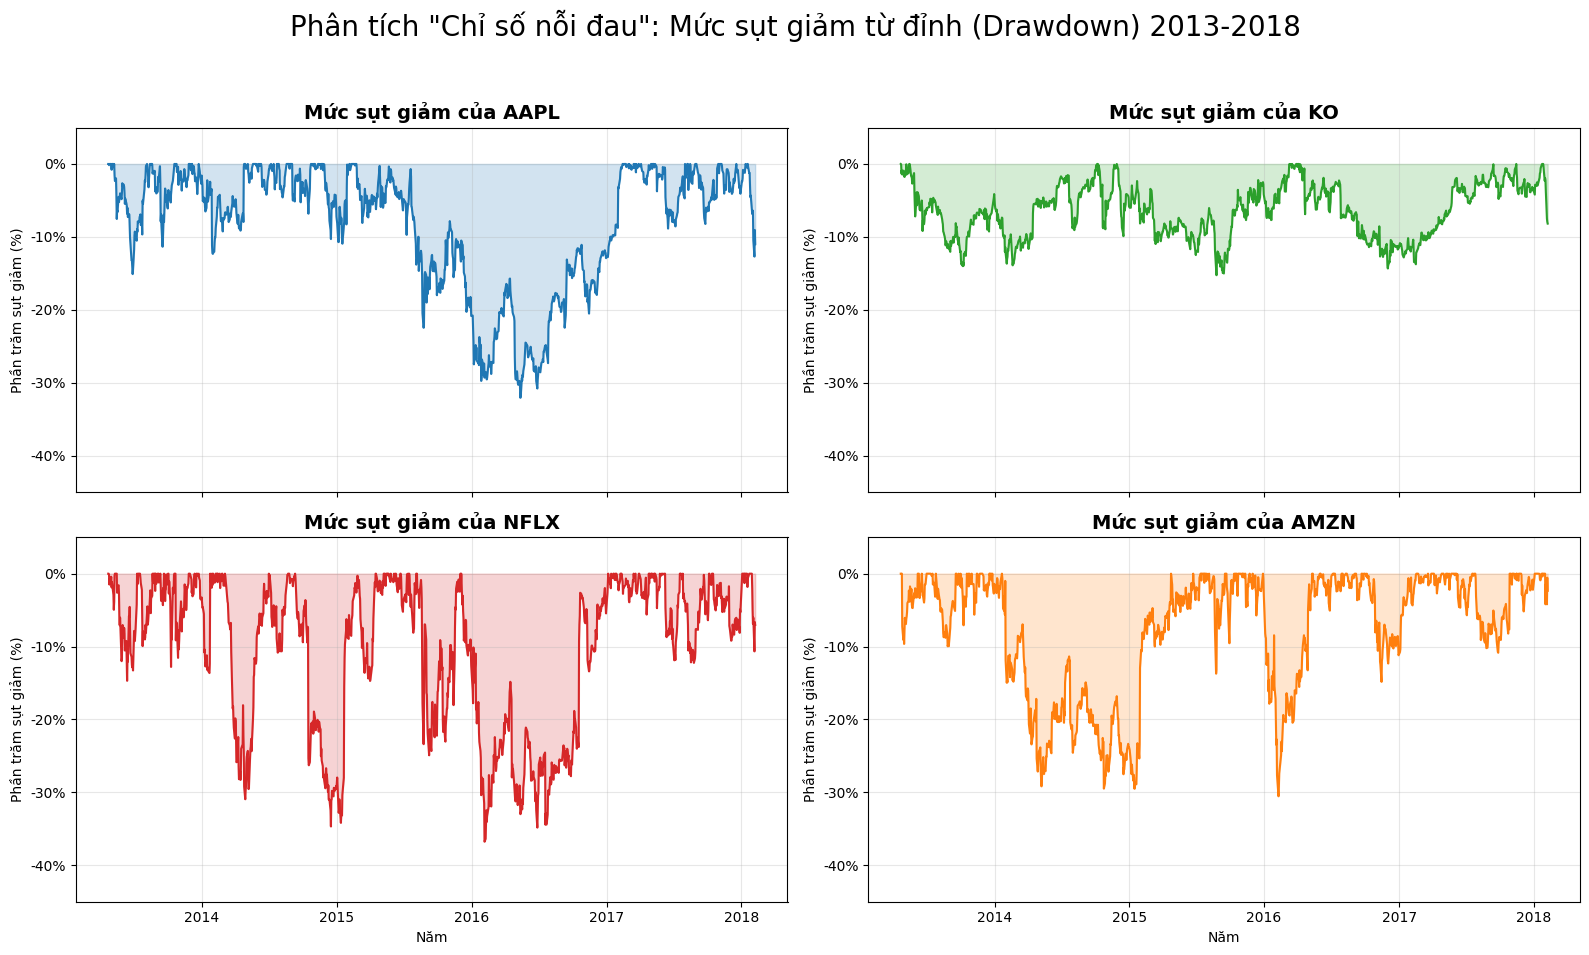

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Thiết lập khung hình 2 hàng, 2 cột
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
fig.suptitle('Phân tích "Chỉ số nỗi đau": Mức sụt giảm từ đỉnh (Drawdown) 2013-2018', fontsize=20)

# Danh sách mã và màu sắc đặc trưng
tickers = ['AAPL', 'KO', 'NFLX', 'AMZN']
colors = ['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e']

# 2. Vòng lặp vẽ từng biểu đồ
for i, ticker in enumerate(tickers):
    row, col = i // 2, i % 2
    data_ticker = df_growth[df_growth['Name'] == ticker]

    # Vẽ đường Drawdown
    sns.lineplot(data=data_ticker, x='date', y='Drawdown',
                 ax=axes[row, col], color=colors[i], linewidth=1.5)

    # Đổ màu vùng dưới đường Drawdown để nhấn mạnh "nỗi đau" (vùng lỗ)
    axes[row, col].fill_between(data_ticker['date'], data_ticker['Drawdown'], 0,
                                 color=colors[i], alpha=0.2)

    # Tùy chỉnh thẩm mỹ
    axes[row, col].set_title(f'Mức sụt giảm của {ticker}', fontsize=14, fontweight='bold')
    axes[row, col].set_ylabel('Phần trăm sụt giảm (%)')
    axes[row, col].set_xlabel('Năm')
    axes[row, col].grid(True, alpha=0.3)

    # Giới hạn trục Y giống nhau (từ 0% xuống -45%) để so sánh độ sâu của cú rơi
    axes[row, col].set_ylim(-0.45, 0.05)

    # Định dạng nhãn trục Y thành phần trăm
    axes[row, col].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('separated_drawdown.png', dpi=300)
plt.show()